In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

from matplotlib.patches import Patch



In [2]:
df = pd.read_csv("../results/df_total.csv")

In [3]:
df.head()

,Dataset,Method,Stride,Execution_Time(s),AUC_Global,Num_Drifts,Num_Windows,Score_List,Drift_List,AUC_List,Timestamp,Windows size,Anomaly threshold,offline_size
0,S1,tumbling_window_1,-,1.04,0.8063,3,69,"[0.315, 0.37, 0.42, 0.395, 0.335, 0.865, 0.375...","[False, False, False, False, False, True, Fals...","[0.98989898989899, 0.9824120603015075, 0.96700...",2026-02-10 13:55:35,200,0.5,1000
1,S1,sliding_window_1,1,79.83,0.6513,3,13999,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9974747474747475, 0.9974747474747475, 0.997...",2026-02-10 13:56:55,200,0.5,1000
2,S1,sliding_window_10,10,10.87,0.8053,12,1400,"[1.0, 0.31, 0.3, 0.29, 0.3, 0.3, 0.315, 0.32, ...","[True, False, False, False, False, False, Fals...","[0.8156565656565656, 0.9848484848484849, 0.975...",2026-02-10 13:57:06,200,0.5,1000
3,S1,sliding_window_50,50,1.94,0.5230,0,280,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9494949494949495, 0.634517766497462, 0.0, 0...",2026-02-10 13:57:08,200,0.5,1000
4,S1,sliding_window_100,100,0.99,0.5236,0,140,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9494949494949495, 0.0, 0.002512562814070362...",2026-02-10 13:57:09,200,0.5,1000


In [4]:
df.Method.unique()

array(['tumbling_window_1', 'sliding_window_1', 'sliding_window_10',
       'sliding_window_50', 'sliding_window_100', 'sliding_window_200',
       'tumbling_window_domain_adaption'], dtype=object)

In [5]:
def change_name(x : str):
    if x =='tumbling_window_1':
        return "Tumbling"
    if x== 'sliding_window_1':
        return 'Sliding s=1'
    if x== 'sliding_window_10':
        return 'Sliding s=10'
    if x== 'sliding_window_50':
        return 'Sliding s=50'
    if x== 'sliding_window_100':
        return 'Sliding s=100'
    if x== 'sliding_window_200':
        return 'Sliding s=200'
    
    if x== 'tumbling_window_domain_adaption':
        return 'Sliding domain adaptation'
    

df["Method"] =  df['Method'].apply(change_name)

In [6]:
df

,Dataset,Method,Stride,Execution_Time(s),AUC_Global,Num_Drifts,Num_Windows,Score_List,Drift_List,AUC_List,Timestamp,Windows size,Anomaly threshold,offline_size
0,S1,Tumbling,-,1.04,0.8063,3,69,"[0.315, 0.37, 0.42, 0.395, 0.335, 0.865, 0.375...","[False, False, False, False, False, True, Fals...","[0.98989898989899, 0.9824120603015075, 0.96700...",2026-02-10 13:55:35,200,0.5,1000
1,S1,Sliding s=1,1,79.83,0.6513,3,13999,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9974747474747475, 0.9974747474747475, 0.997...",2026-02-10 13:56:55,200,0.5,1000
2,S1,Sliding s=10,10,10.87,0.8053,12,1400,"[1.0, 0.31, 0.3, 0.29, 0.3, 0.3, 0.315, 0.32, ...","[True, False, False, False, False, False, Fals...","[0.8156565656565656, 0.9848484848484849, 0.975...",2026-02-10 13:57:06,200,0.5,1000
3,S1,Sliding s=50,50,1.94,0.5230,0,280,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9494949494949495, 0.634517766497462, 0.0, 0...",2026-02-10 13:57:08,200,0.5,1000
4,S1,Sliding s=100,100,0.99,0.5236,0,140,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9494949494949495, 0.0, 0.002512562814070362...",2026-02-10 13:57:09,200,0.5,1000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,WOBC_shake_sudden,Sliding s=10,10,9.28,0.7297,0,2900,"[0.22, 0.28, 0.3, 0.32, 0.36, 0.3, 0.24, 0.24,...","[False, False, False, False, False, False, Fal...","[0.9591836734693877, 0.9183673469387755, 0.897...",2026-02-10 18:52:45,50,0.7,1000
770,WOBC_shake_sudden,Sliding s=50,50,2.29,0.7303,0,579,"[0.22, 0.3, 0.34, 0.26, 0.2, 0.28, 0.3, 0.24, ...","[False, False, False, False, False, False, Fal...","[0.9591836734693877, 0.6938775510204082, 0.591...",2026-02-10 18:52:47,50,0.7,1000
771,WOBC_shake_sudden,Sliding s=100,100,1.14,0.7406,0,290,"[0.22, 0.34, 0.2, 0.3, 0.26, 0.28, 0.2, 0.26, ...","[False, False, False, False, False, False, Fal...","[0.9591836734693877, 0.5918367346938775, 0.918...",2026-02-10 18:52:49,50,0.7,1000
772,WOBC_shake_sudden,Sliding s=200,200,0.52,0.7535,0,145,"[0.22, 0.2, 0.26, 0.2, 0.28, 0.24, 0.3, 0.32, ...","[False, False, False, False, False, False, Fal...","[0.9591836734693877, 0.9183673469387755, 0.897...",2026-02-10 18:52:49,50,0.7,1000


In [7]:
df

,Dataset,Method,Stride,Execution_Time(s),AUC_Global,Num_Drifts,Num_Windows,Score_List,Drift_List,AUC_List,Timestamp,Windows size,Anomaly threshold,offline_size
0,S1,Tumbling,-,1.04,0.8063,3,69,"[0.315, 0.37, 0.42, 0.395, 0.335, 0.865, 0.375...","[False, False, False, False, False, True, Fals...","[0.98989898989899, 0.9824120603015075, 0.96700...",2026-02-10 13:55:35,200,0.5,1000
1,S1,Sliding s=1,1,79.83,0.6513,3,13999,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9974747474747475, 0.9974747474747475, 0.997...",2026-02-10 13:56:55,200,0.5,1000
2,S1,Sliding s=10,10,10.87,0.8053,12,1400,"[1.0, 0.31, 0.3, 0.29, 0.3, 0.3, 0.315, 0.32, ...","[True, False, False, False, False, False, Fals...","[0.8156565656565656, 0.9848484848484849, 0.975...",2026-02-10 13:57:06,200,0.5,1000
3,S1,Sliding s=50,50,1.94,0.5230,0,280,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9494949494949495, 0.634517766497462, 0.0, 0...",2026-02-10 13:57:08,200,0.5,1000
4,S1,Sliding s=100,100,0.99,0.5236,0,140,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[False, False, False, False, False, False, Fal...","[0.9494949494949495, 0.0, 0.002512562814070362...",2026-02-10 13:57:09,200,0.5,1000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,WOBC_shake_sudden,Sliding s=10,10,9.28,0.7297,0,2900,"[0.22, 0.28, 0.3, 0.32, 0.36, 0.3, 0.24, 0.24,...","[False, False, False, False, False, False, Fal...","[0.9591836734693877, 0.9183673469387755, 0.897...",2026-02-10 18:52:45,50,0.7,1000
770,WOBC_shake_sudden,Sliding s=50,50,2.29,0.7303,0,579,"[0.22, 0.3, 0.34, 0.26, 0.2, 0.28, 0.3, 0.24, ...","[False, False, False, False, False, False, Fal...","[0.9591836734693877, 0.6938775510204082, 0.591...",2026-02-10 18:52:47,50,0.7,1000
771,WOBC_shake_sudden,Sliding s=100,100,1.14,0.7406,0,290,"[0.22, 0.34, 0.2, 0.3, 0.26, 0.28, 0.2, 0.26, ...","[False, False, False, False, False, False, Fal...","[0.9591836734693877, 0.5918367346938775, 0.918...",2026-02-10 18:52:49,50,0.7,1000
772,WOBC_shake_sudden,Sliding s=200,200,0.52,0.7535,0,145,"[0.22, 0.2, 0.26, 0.2, 0.28, 0.24, 0.3, 0.32, ...","[False, False, False, False, False, False, Fal...","[0.9591836734693877, 0.9183673469387755, 0.897...",2026-02-10 18:52:49,50,0.7,1000


## 1 - Combine All Dataset   for ROC

In [8]:
df.columns

Index(['Dataset', 'Method', 'Stride', 'Execution_Time(s)', 'AUC_Global',
       'Num_Drifts', 'Num_Windows', 'Score_List', 'Drift_List', 'AUC_List',
       'Timestamp', 'Windows size', 'Anomaly threshold', 'offline_size'],
      dtype='object')

In [9]:
filenames = np.unique(df['Dataset'])

In [10]:
filenames

array(['COIL20_mix_sudden', 'Ionosphere_shake_gradual',
       'Ionosphere_shake_sudden_2', 'S1', 'S2', 'WOBC_shake_gradual_2',
       'WOBC_shake_sudden', 'dermatology_shake_gradual',
       'dermatology_shake_sudden_2', 'glass_shake_gradual_2',
       'glass_shake_sudden_2', 'mice_shake_gradual_2',
       'mice_shake_sudden', 'seeds_shake_gradual',
       'thyroid_shake_gradual', 'vowel_shake_gradual',
       'vowel_shake_sudden_2', 'wine_shake_sudden', 'wine_shake_sudden_2'],
      dtype=object)

In [11]:

pivot_auc = df.pivot_table(
    index='Dataset', 
    columns='Method', 
    values='AUC_Global', 
    aggfunc='mean'
)

pivot_std = df.pivot_table(
    index='Dataset', 
    columns='Method', 
    values='AUC_Global', 
    aggfunc='std'
)

df_finalt = pivot_auc.applymap(lambda x: f"{x:.3f}") + " $\pm$ " + pivot_std.applymap(lambda x: f"{x:.3f}")


pivot_time = df.pivot_table(
    index='Dataset', 
    columns='Method', 
    values='Execution_Time(s)', 
    aggfunc='mean'
)

pivot_std_time = df.pivot_table(
    index='Dataset', 
    columns='Method', 
    values='Execution_Time(s)', 
    aggfunc='std'
)
df_time = pivot_time.applymap(lambda x: f"{x:.3f}") + " $\pm$ " + pivot_std_time.applymap(lambda x: f"{x:.3f}")


/tmp/ipykernel_386009/2740151824.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_finalt = pivot_auc.applymap(lambda x: f"{x:.3f}") + " $\pm$ " + pivot_std.applymap(lambda x: f"{x:.3f}")
/tmp/ipykernel_386009/2740151824.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_time = pivot_time.applymap(lambda x: f"{x:.3f}") + " $\pm$ " + pivot_std_time.applymap(lambda x: f"{x:.3f}")


In [12]:
pivot_time

Method,Sliding domain adaptation,Sliding s=1,Sliding s=10,Sliding s=100,Sliding s=200,Sliding s=50,Tumbling
Dataset,,,,,,,
COIL20_mix_sudden,915.140000,1846.121667,190.086667,331.931667,15.795000,47.898333,21.560000
Ionosphere_shake_gradual,71.330000,222.605000,24.013333,2.365000,1.245000,4.691667,2.105000
Ionosphere_shake_sudden_2,123.841667,301.681667,30.405000,3.216667,1.595000,6.133333,2.663333
S1,12.543333,59.895000,7.575000,0.740000,0.341667,1.838333,1.093333
S2,7.986667,18.943333,2.006667,0.210000,0.105000,0.425000,0.153333
WOBC_shake_gradual_2,105.118333,252.943333,25.621667,2.781667,1.333333,5.233333,2.075000
WOBC_shake_sudden,36.586667,147.993333,16.631667,1.595000,0.808333,3.098333,1.595000
dermatology_shake_gradual,90.275000,268.671667,27.618333,3.398333,2.450000,6.296667,3.425000
dermatology_shake_sudden_2,109.995000,299.421667,31.625000,4.128333,2.323333,7.771667,3.563333


In [13]:
#df_finalt.to_latex("../results/data/resultauc_results.tex")
#df_time.to_latex("../results/data/resultauc_results_time.tex")

In [14]:
df_sota_text = pd.read_csv("../results/data/result_sota_text.csv")
df_sota_roc =  pd.read_csv("../results/data/result_sota__roc_roc.csv")
df_sota_time =  pd.read_csv("../results/data/result_sota__roc_time.csv")

In [15]:
df_sota_text

,Dataset,HSTree,IForestASD,LODA,RSHash,xStream
0,COIL20_mix_sudden,\textbf{0.9248 ± 0.0030},0.9177 ± 0.0507,0.5000 ± 0.0001,0.9055 ± 0.0099,0.9100 ± 0.0598
1,Ionosphere_shake_gradual,0.7308 ± 0.0009,\textbf{0.9744 ± 0.0082},0.4992 ± 0.0008,0.7326 ± 0.0003,0.9131 ± 0.0145
2,Ionosphere_shake_sudden_2,0.7295 ± 0.0021,\textbf{0.9700 ± 0.0125},0.5000 ± 0.0000,0.7338 ± 0.0005,0.9153 ± 0.0071
3,S1,0.8751 ± 0.0028,\textbf{0.9802 ± 0.0041},0.6123 ± 0.1588,0.9639 ± 0.0061,0.9196 ± 0.0514
4,S2,0.5729 ± 0.0598,\textbf{0.5960 ± 0.0140},0.5001 ± 0.0001,0.5492 ± 0.0146,0.5072 ± 0.0506
5,WOBC_shake_gradual_2,0.7284 ± 0.0036,0.9205 ± 0.0086,0.5000 ± 0.0000,0.7332 ± 0.0009,\textbf{0.9511 ± 0.0368}
6,WOBC_shake_sudden,0.7269 ± 0.0075,0.9403 ± 0.0032,0.5001 ± 0.0001,0.7334 ± 0.0042,\textbf{0.9522 ± 0.0385}
7,dermatology_shake_gradual,0.7431 ± 0.0017,0.9795 ± 0.0129,0.5000 ± 0.0000,0.7300 ± 0.0015,\textbf{0.9885 ± 0.0101}
8,dermatology_shake_sudden_2,0.7313 ± 0.0010,0.9790 ± 0.0083,0.5000 ± 0.0000,0.7101 ± 0.0045,\textbf{0.9879 ± 0.0113}
9,glass_shake_gradual_2,0.7413 ± 0.0063,\textbf{0.9836 ± 0.0020},0.5000 ± 0.0000,0.7530 ± 0.0005,0.9201 ± 0.0008


In [16]:
df_sota_text.index = df_sota_text['Dataset']
df_sota_text = df_sota_text.drop(columns=['Dataset'])

In [17]:
df_sota_text

,HSTree,IForestASD,LODA,RSHash,xStream
Dataset,,,,,
COIL20_mix_sudden,\textbf{0.9248 ± 0.0030},0.9177 ± 0.0507,0.5000 ± 0.0001,0.9055 ± 0.0099,0.9100 ± 0.0598
Ionosphere_shake_gradual,0.7308 ± 0.0009,\textbf{0.9744 ± 0.0082},0.4992 ± 0.0008,0.7326 ± 0.0003,0.9131 ± 0.0145
Ionosphere_shake_sudden_2,0.7295 ± 0.0021,\textbf{0.9700 ± 0.0125},0.5000 ± 0.0000,0.7338 ± 0.0005,0.9153 ± 0.0071
S1,0.8751 ± 0.0028,\textbf{0.9802 ± 0.0041},0.6123 ± 0.1588,0.9639 ± 0.0061,0.9196 ± 0.0514
S2,0.5729 ± 0.0598,\textbf{0.5960 ± 0.0140},0.5001 ± 0.0001,0.5492 ± 0.0146,0.5072 ± 0.0506
WOBC_shake_gradual_2,0.7284 ± 0.0036,0.9205 ± 0.0086,0.5000 ± 0.0000,0.7332 ± 0.0009,\textbf{0.9511 ± 0.0368}
WOBC_shake_sudden,0.7269 ± 0.0075,0.9403 ± 0.0032,0.5001 ± 0.0001,0.7334 ± 0.0042,\textbf{0.9522 ± 0.0385}
dermatology_shake_gradual,0.7431 ± 0.0017,0.9795 ± 0.0129,0.5000 ± 0.0000,0.7300 ± 0.0015,\textbf{0.9885 ± 0.0101}
dermatology_shake_sudden_2,0.7313 ± 0.0010,0.9790 ± 0.0083,0.5000 ± 0.0000,0.7101 ± 0.0045,\textbf{0.9879 ± 0.0113}


In [18]:
#pd.concat([df_sota_text, df_finalt] , axis=1).to_latex("../results/data/combine_result.tex")

In [19]:
combine = pd.concat([df_sota_text, df_finalt] , axis=1)

# 2 - Combine All dataset for time

In [20]:
df_time

Method,Sliding domain adaptation,Sliding s=1,Sliding s=10,Sliding s=100,Sliding s=200,Sliding s=50,Tumbling
Dataset,,,,,,,
COIL20_mix_sudden,915.140 $\pm$ 57.926,1846.122 $\pm$ 127.242,190.087 $\pm$ 17.132,331.932 $\pm$ 746.698,15.795 $\pm$ 5.653,47.898 $\pm$ 11.657,21.560 $\pm$ 10.257
Ionosphere_shake_gradual,71.330 $\pm$ 50.274,222.605 $\pm$ 45.468,24.013 $\pm$ 6.487,2.365 $\pm$ 0.419,1.245 $\pm$ 0.216,4.692 $\pm$ 1.003,2.105 $\pm$ 1.009
Ionosphere_shake_sudden_2,123.842 $\pm$ 65.487,301.682 $\pm$ 60.588,30.405 $\pm$ 6.955,3.217 $\pm$ 0.605,1.595 $\pm$ 0.274,6.133 $\pm$ 1.019,2.663 $\pm$ 0.770
S1,12.543 $\pm$ 10.718,59.895 $\pm$ 18.061,7.575 $\pm$ 2.815,0.740 $\pm$ 0.270,0.342 $\pm$ 0.105,1.838 $\pm$ 1.047,1.093 $\pm$ 0.131
S2,7.987 $\pm$ 4.810,18.943 $\pm$ 6.107,2.007 $\pm$ 0.665,0.210 $\pm$ 0.047,0.105 $\pm$ 0.029,0.425 $\pm$ 0.144,0.153 $\pm$ 0.055
WOBC_shake_gradual_2,105.118 $\pm$ 58.694,252.943 $\pm$ 59.739,25.622 $\pm$ 5.950,2.782 $\pm$ 0.601,1.333 $\pm$ 0.306,5.233 $\pm$ 1.038,2.075 $\pm$ 0.685
WOBC_shake_sudden,36.587 $\pm$ 32.241,147.993 $\pm$ 29.090,16.632 $\pm$ 5.302,1.595 $\pm$ 0.275,0.808 $\pm$ 0.171,3.098 $\pm$ 0.507,1.595 $\pm$ 0.994
dermatology_shake_gradual,90.275 $\pm$ 14.489,268.672 $\pm$ 93.810,27.618 $\pm$ 7.859,3.398 $\pm$ 1.485,2.450 $\pm$ 1.242,6.297 $\pm$ 2.376,3.425 $\pm$ 1.084
dermatology_shake_sudden_2,109.995 $\pm$ 14.602,299.422 $\pm$ 64.892,31.625 $\pm$ 7.642,4.128 $\pm$ 1.280,2.323 $\pm$ 0.879,7.772 $\pm$ 2.312,3.563 $\pm$ 0.899


In [21]:
df_sota_roc

,Dataset,HSTree,IForestASD,LODA,RSHash,xStream
0,COIL20_mix_sudden,0.924800,0.917700,0.500033,0.905467,0.910000
1,Ionosphere_shake_gradual,0.730833,0.974367,0.499200,0.732567,0.913050
2,Ionosphere_shake_sudden_2,0.729500,0.970033,0.500000,0.733800,0.915350
3,S1,0.875100,0.980200,0.612300,0.963900,0.919650
4,S2,0.572950,0.596000,0.500100,0.549150,0.507250
5,WOBC_shake_gradual_2,0.728400,0.920533,0.500000,0.733200,0.951100
6,WOBC_shake_sudden,0.726900,0.940300,0.500067,0.733433,0.952200
7,dermatology_shake_gradual,0.743133,0.979500,0.500000,0.730033,0.988533
8,dermatology_shake_sudden_2,0.731333,0.979033,0.500000,0.710067,0.987900
9,glass_shake_gradual_2,0.741333,0.983567,0.500000,0.753000,0.920100


In [22]:
df_sota_time.index = df_sota_time['Dataset']


In [23]:
df_sota_time =  df_sota_time.drop(["Dataset"], axis=1)

In [24]:
df_sota_time

,HSTree,IForestASD,LODA,RSHash,xStream
Dataset,,,,,
COIL20_mix_sudden,423.754533,1898.944300,315.603167,97.024633,6500.906300
Ionosphere_shake_gradual,564.905367,289.639133,358.535367,883.348400,5788.902750
Ionosphere_shake_sudden_2,707.107233,302.726600,447.538000,164.750367,7433.178000
S1,317.373450,37.952500,192.718300,44.334150,4157.024700
S2,123.268800,22.282700,81.245350,18.158600,899.901250
WOBC_shake_gradual_2,958.272333,298.950300,479.609533,194.327267,14901.678600
WOBC_shake_sudden,504.034133,270.485600,261.304867,101.444600,6194.307400
dermatology_shake_gradual,564.265300,284.821733,358.585833,138.356367,8122.839367
dermatology_shake_sudden_2,705.775967,293.605400,2483.599433,162.249500,7438.824850


In [25]:
time_all = pd.concat([pivot_time,df_sota_time ], axis=1)

In [26]:
time_all

,Sliding domain adaptation,Sliding s=1,Sliding s=10,Sliding s=100,Sliding s=200,Sliding s=50,Tumbling,HSTree,IForestASD,LODA,RSHash,xStream
Dataset,,,,,,,,,,,,
COIL20_mix_sudden,915.140000,1846.121667,190.086667,331.931667,15.795000,47.898333,21.560000,423.754533,1898.944300,315.603167,97.024633,6500.906300
Ionosphere_shake_gradual,71.330000,222.605000,24.013333,2.365000,1.245000,4.691667,2.105000,564.905367,289.639133,358.535367,883.348400,5788.902750
Ionosphere_shake_sudden_2,123.841667,301.681667,30.405000,3.216667,1.595000,6.133333,2.663333,707.107233,302.726600,447.538000,164.750367,7433.178000
S1,12.543333,59.895000,7.575000,0.740000,0.341667,1.838333,1.093333,317.373450,37.952500,192.718300,44.334150,4157.024700
S2,7.986667,18.943333,2.006667,0.210000,0.105000,0.425000,0.153333,123.268800,22.282700,81.245350,18.158600,899.901250
WOBC_shake_gradual_2,105.118333,252.943333,25.621667,2.781667,1.333333,5.233333,2.075000,958.272333,298.950300,479.609533,194.327267,14901.678600
WOBC_shake_sudden,36.586667,147.993333,16.631667,1.595000,0.808333,3.098333,1.595000,504.034133,270.485600,261.304867,101.444600,6194.307400
dermatology_shake_gradual,90.275000,268.671667,27.618333,3.398333,2.450000,6.296667,3.425000,564.265300,284.821733,358.585833,138.356367,8122.839367
dermatology_shake_sudden_2,109.995000,299.421667,31.625000,4.128333,2.323333,7.771667,3.563333,705.775967,293.605400,2483.599433,162.249500,7438.824850


# 3 Trade-off Between time and AUC

In [27]:
pivot_auc

Method,Sliding domain adaptation,Sliding s=1,Sliding s=10,Sliding s=100,Sliding s=200,Sliding s=50,Tumbling
Dataset,,,,,,,
COIL20_mix_sudden,0.506050,0.740717,0.739417,0.731267,0.758267,0.727200,0.843083
Ionosphere_shake_gradual,0.729825,0.778533,0.747933,0.748783,0.746583,0.747450,0.789367
Ionosphere_shake_sudden_2,0.790733,0.799600,0.790633,0.790700,0.788783,0.790450,0.810550
S1,0.610900,0.665167,0.760350,0.568883,0.583417,0.654000,0.783250
S2,0.682250,0.673000,0.673133,0.673183,0.695600,0.676433,0.703233
WOBC_shake_gradual_2,0.621900,0.623517,0.621783,0.625100,0.627100,0.621800,0.634133
WOBC_shake_sudden,0.691933,0.669700,0.632483,0.627683,0.631583,0.625783,0.679450
dermatology_shake_gradual,0.687000,0.733450,0.730850,0.728700,0.725083,0.729733,0.746967
dermatology_shake_sudden_2,0.698000,0.749150,0.764567,0.761867,0.753517,0.758233,0.753567


In [28]:
df_sota_roc.index = df_sota_roc['Dataset']

df_sota_roc =  df_sota_roc.drop(["Dataset"], axis=1)

In [29]:
all_auc = pd.DataFrame(pd.concat([df_sota_roc,pivot_auc ], axis=1))

Friedman p-value : 0.0000


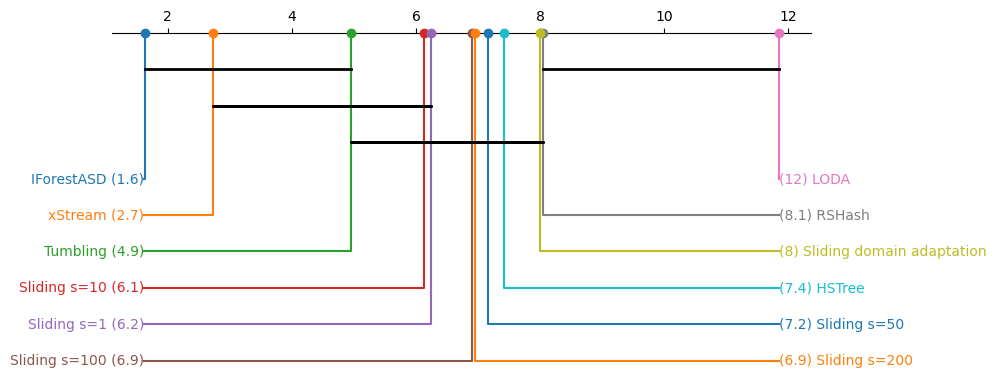

In [30]:
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare



stat, p = friedmanchisquare(*[all_auc[col] for col in all_auc.columns])
print(f"Friedman p-value : {p:.4f}")

ranks = all_auc.rank(axis=1, ascending=False).mean()

sig_matrix = sp.posthoc_nemenyi_friedman(all_auc)

plt.figure(figsize=(10, 4))
sp.critical_difference_diagram(ranks, sig_matrix)
plt.tight_layout()
plt.savefig("../results/data/cd_diagram.eps")
plt.show()

In [31]:
#pd.concat([pivot_time,df_sota_time ], axis=1).to_latex('../results/data/combine_time.tex')

In [32]:
df_sc_time = time_all.mean().to_frame(name='Time').reset_index().sort_values("index")
print(df_sc_time.columns) 
df_sc_time.columns = ["Method", "Time"]

Index(['index', 'Time'], dtype='object')


In [33]:
df_sc_time

,Method,Time
7,HSTree,621.684476
8,IForestASD,346.240565
9,LODA,657.321564
10,RSHash,171.224182
0,Sliding domain adaptation,177.961053
1,Sliding s=1,352.199123
2,Sliding s=10,31.786228
3,Sliding s=100,19.871053
4,Sliding s=200,2.136228
5,Sliding s=50,7.095702


In [34]:
df_sc_auc = all_auc.mean().to_frame(name='AUC').reset_index().sort_values("index")
print(df_sc_auc.columns) 


Index(['index', 'AUC'], dtype='object')


In [35]:
df_sc_auc.columns = ["Method", "AUC"]

In [36]:
df_sc_auc

,Method,AUC
0,HSTree,0.742599
1,IForestASD,0.951242
2,LODA,0.505902
3,RSHash,0.740075
5,Sliding domain adaptation,0.723999
6,Sliding s=1,0.753473
7,Sliding s=10,0.756869
8,Sliding s=100,0.742702
9,Sliding s=200,0.744859
10,Sliding s=50,0.748397


In [42]:
df_plot = pd.merge(df_sc_time, df_sc_auc, on='Method')



In [40]:
df_plot

,Method,Time,AUC
0,HSTree,621.684476,0.742599
1,IForestASD,346.240565,0.951242
2,LODA,657.321564,0.505902
3,RSHash,171.224182,0.740075
4,Sliding domain adaptation,177.961053,0.723999
5,Sliding s=1,352.199123,0.753473
6,Sliding s=10,31.786228,0.756869
7,Sliding s=100,19.871053,0.742702
8,Sliding s=200,2.136228,0.744859
9,Sliding s=50,7.095702,0.748397


In [60]:
df_plot

,Method,Time,AUC,Category
0,HSTree,621.684476,0.742599,SOTA
1,IForestASD,346.240565,0.951242,SOTA
2,LODA,657.321564,0.505902,SOTA
3,RSHash,171.224182,0.740075,SOTA
4,Sliding domain adaptation,177.961053,0.723999,Proposed
5,Sliding s=1,352.199123,0.753473,Proposed
6,Sliding s=10,31.786228,0.756869,Proposed
7,Sliding s=100,19.871053,0.742702,Proposed
8,Sliding s=200,2.136228,0.744859,Proposed
9,Sliding s=50,7.095702,0.748397,Proposed


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


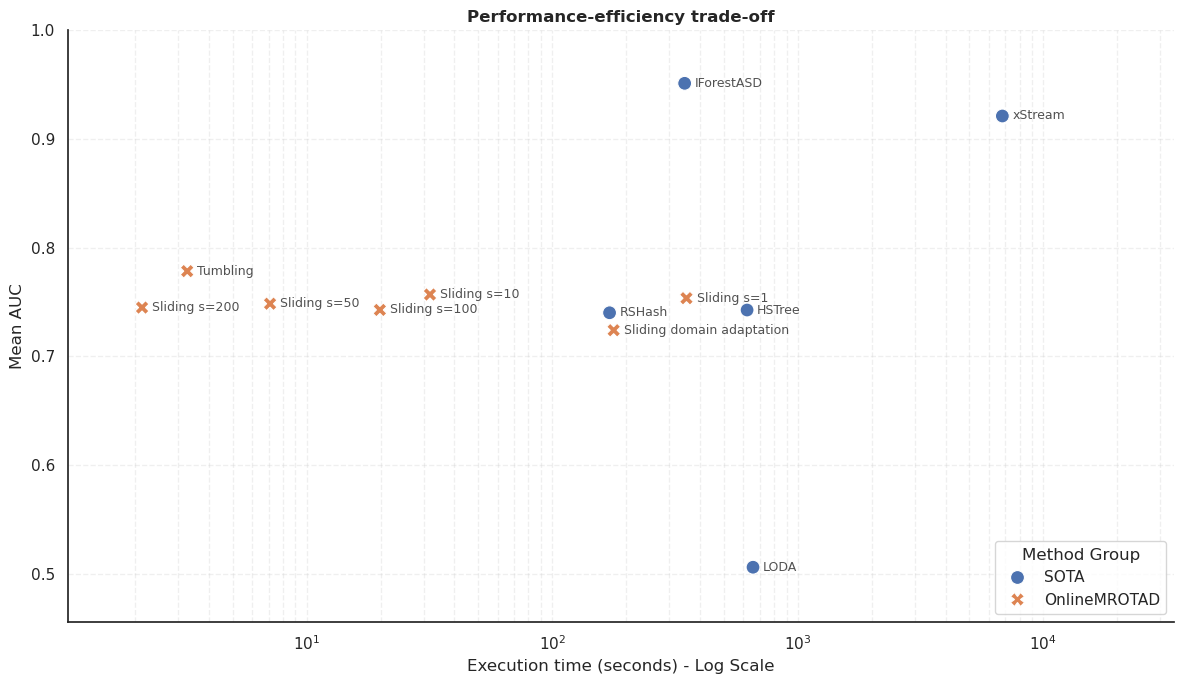

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white") 
plt.figure(figsize=(12, 7))

df_plot['Category'] = df_plot['Method'].apply(
    lambda x: 'OnlineMROTAD' if 'Sliding' in x or 'Tumbling' in x else 'SOTA'
)

plot = sns.scatterplot(
    data=df_plot, 
    x="Time",     
    y="AUC",    
    hue="Category", 
    style="Category", 
    s=100)


for i in range(df_plot.shape[0]):
    plt.text(
        x=df_plot.Time.iloc[i] * 1.1,
        y=df_plot.AUC.iloc[i], 
        s=df_plot.Method.iloc[i], 
        fontsize=9,
        alpha=0.8,
        verticalalignment='center'
    )

plt.xscale("log") 
plt.title("Performance-efficiency trade-off", fontsize=12, fontweight='bold')
plt.xlabel("Execution time (seconds) - Log Scale", fontsize=12)
plt.ylabel("Mean AUC", fontsize=12)

plt.xlim(df_plot.Time.min() * 0.5, df_plot.Time.max() * 5)
plt.ylim(df_plot.AUC.min() - 0.05, 1.0)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(title='Method Group', loc='lower right', frameon=True)
sns.despine()

plt.tight_layout()
plt.savefig("../results/data/trade_off.eps")
plt.show()

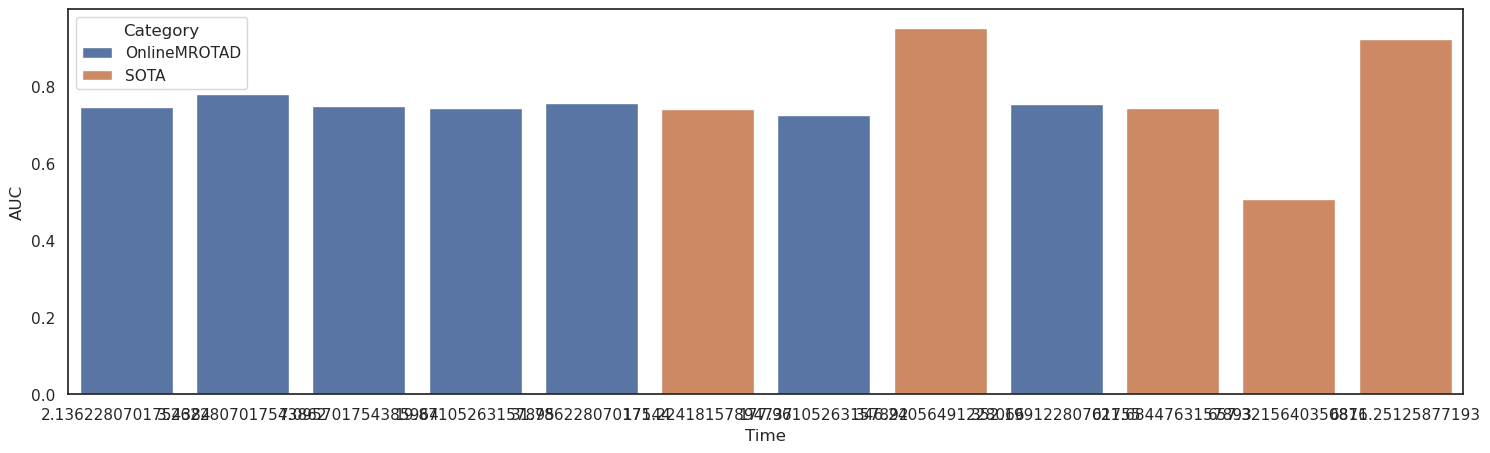

In [66]:
plt.figure(figsize=(18, 5))

sns.barplot(data=df_plot, x="Time", y="AUC", hue='Category')
plt.xticks()
plt.show()

In [ ]:
import pandas as pd

def generer_latex_depuis_df(chemin_csv):
    df = pd.read_csv(chemin_csv)


    df_clean = df.sort_values(by=['AUC_Global', 'Execution_Time(s)'], 
                             ascending=[False, True]).groupby(['Dataset', 'Method']).first().reset_index()
    
    df_clean["Method"] =  df_clean['Method'].apply(change_name)
    pivot_auc = df_clean.pivot(index='Dataset', columns='Method', values='AUC_Global')
    pivot_time = df_clean.pivot(index='Dataset', columns='Method', values='Execution_Time(s)')

    algos = pivot_auc.columns.tolist()
    header_algos = " & ".join([f"\\textbf{{{a.replace('_', ' ')}}}" for a in algos])
    col_format = "l" + "c" * len(algos)

    latex_rows = []
    for dataset in pivot_auc.index:
        # Protection des underscores pour LaTeX
        ds_name = dataset.replace('_', '\\_')
        row_str = ds_name
        
        # Trouver la valeur max de la ligne pour le gras
        max_auc = pivot_auc.loc[dataset].max()
        
        for algo in algos:
            auc = pivot_auc.loc[dataset, algo]
            time = pivot_time.loc[dataset, algo]
            
            if pd.isna(auc):
                cell = "N/A"
            else:
                val_text = f"{auc:.4f} ({time:.1f}s)"
              
                if auc == max_auc:
                    cell = f"\\textbf{{{val_text}}}"
                else:
                    cell = val_text
            
            row_str += f" & {cell}"
        
        row_str += " \\\\"
        latex_rows.append(row_str)

    latex_table = f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Comparaison des performances ROC et temps d'exécution}}
\\label{{tab:resultats_algos}}
\\resizebox{{\\textwidth}}{{!}}{{% Force le tableau à tenir sur la largeur de la page
\\begin{{tabular}}{{{col_format}}}
\\toprule
\\textbf{{Dataset}} & {header_algos} \\\\
\\midrule
"""
    latex_table += "\n".join(latex_rows)
    latex_table += """
\\bottomrule
\\end{tabular}
}
\\end{table}
"""
    return latex_table, pivot_auc


In [ ]:

code_latex, pivot_auc = generer_latex_depuis_df('../results/df_total.csv')
#print(code_latex)

In [ ]:
pivot_auc

Method,Sliding domain adaptation,Sliding s=1,Sliding s=10,Sliding s=100,Sliding s=200,Sliding s=50,Tumbling
Dataset,,,,,,,
COIL20_mix_sudden,0.5065,0.9110,0.9206,0.8467,0.9093,0.8757,0.9185
Ionosphere_shake_gradual,0.7873,0.8006,0.7978,0.7981,0.7954,0.7994,0.8007
Ionosphere_shake_sudden_2,0.8227,0.8228,0.8226,0.8231,0.8184,0.8224,0.8221
S1,0.6733,0.7124,0.8053,0.6768,0.6624,0.7939,0.8063
S2,0.7659,0.7154,0.7151,0.7206,0.8158,0.7192,0.7659
WOBC_shake_gradual_2,0.6972,0.6972,0.6971,0.6973,0.6983,0.6972,0.7006
WOBC_shake_sudden,0.7297,0.7297,0.7297,0.7406,0.7535,0.7303,0.7303
dermatology_shake_gradual,0.7037,0.7699,0.7572,0.7626,0.7626,0.7613,0.7649
dermatology_shake_sudden_2,0.7941,0.7994,0.8292,0.8303,0.8291,0.8061,0.7834


In [ ]:
pivot_auc

Method,Sliding domain adaptation,Sliding s=1,Sliding s=10,Sliding s=100,Sliding s=200,Sliding s=50,Tumbling
Dataset,,,,,,,
COIL20_mix_sudden,0.5065,0.9110,0.9206,0.8467,0.9093,0.8757,0.9185
Ionosphere_shake_gradual,0.7873,0.8006,0.7978,0.7981,0.7954,0.7994,0.8007
Ionosphere_shake_sudden_2,0.8227,0.8228,0.8226,0.8231,0.8184,0.8224,0.8221
S1,0.6733,0.7124,0.8053,0.6768,0.6624,0.7939,0.8063
S2,0.7659,0.7154,0.7151,0.7206,0.8158,0.7192,0.7659
WOBC_shake_gradual_2,0.6972,0.6972,0.6971,0.6973,0.6983,0.6972,0.7006
WOBC_shake_sudden,0.7297,0.7297,0.7297,0.7406,0.7535,0.7303,0.7303
dermatology_shake_gradual,0.7037,0.7699,0.7572,0.7626,0.7626,0.7613,0.7649
dermatology_shake_sudden_2,0.7941,0.7994,0.8292,0.8303,0.8291,0.8061,0.7834


/tmp/ipykernel_372006/1193620463.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pivot_auc.columns, y=pivot_auc.mean(), palette="viridis")


Text(0, 0.5, 'AUC Moyen')

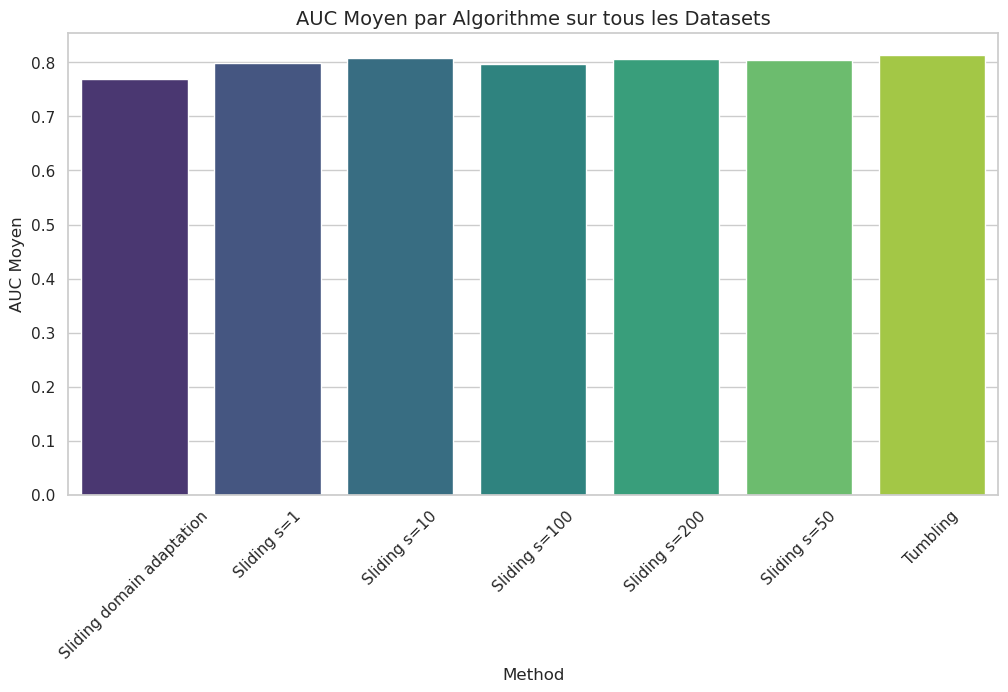

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=pivot_auc.columns, y=pivot_auc.mean(), palette="viridis")
plt.xticks(rotation=45)
plt.title("AUC Moyen par Algorithme sur tous les Datasets", fontsize=14)
plt.ylabel("AUC Moyen")

In [ ]:
sota_auc = pd.read_csv("../results/pivot_roc_sota.csv")

In [ ]:
pivot_auc = pivot_auc.reset_index()

In [ ]:
pivot_auc

Method,Dataset,Sliding domain adaptation,Sliding s=1,Sliding s=10,Sliding s=100,Sliding s=200,Sliding s=50,Tumbling
0,COIL20_mix_sudden,0.5065,0.9110,0.9206,0.8467,0.9093,0.8757,0.9185
1,Ionosphere_shake_gradual,0.7873,0.8006,0.7978,0.7981,0.7954,0.7994,0.8007
2,Ionosphere_shake_sudden_2,0.8227,0.8228,0.8226,0.8231,0.8184,0.8224,0.8221
3,S1,0.6733,0.7124,0.8053,0.6768,0.6624,0.7939,0.8063
4,S2,0.7659,0.7154,0.7151,0.7206,0.8158,0.7192,0.7659
5,WOBC_shake_gradual_2,0.6972,0.6972,0.6971,0.6973,0.6983,0.6972,0.7006
6,WOBC_shake_sudden,0.7297,0.7297,0.7297,0.7406,0.7535,0.7303,0.7303
7,dermatology_shake_gradual,0.7037,0.7699,0.7572,0.7626,0.7626,0.7613,0.7649
8,dermatology_shake_sudden_2,0.7941,0.7994,0.8292,0.8303,0.8291,0.8061,0.7834
9,glass_shake_gradual_2,0.9250,0.9250,0.9250,0.9263,0.9251,0.9251,0.9251


In [ ]:
table2 = pivot_auc.copy()

In [ ]:
pivot = pivot_auc.drop(columns=['Dataset'], inplace=True)

In [ ]:
sota_auc

,HSTree,IForestASD,LODA,RSHash,xStream
0,0.9266,0.9565,0.5001,0.9167,0.9521
1,0.7318,0.9823,0.5000,0.7329,0.9233
2,0.7312,0.9786,0.5000,0.7343,0.9204
3,0.8771,0.9831,0.7246,0.9682,0.9560
4,0.6152,0.6059,0.5002,0.5595,0.5430
5,0.7305,0.9278,0.5000,0.7342,0.9771
6,0.7353,0.9432,0.5001,0.7361,0.9794
7,0.7447,0.9896,0.5000,0.7316,0.9950
8,0.7321,0.9850,0.5000,0.7130,0.9959
9,0.7481,0.9859,0.5000,0.7536,0.9207


In [ ]:
pd.concat([table2, sota_auc], axis=1)

,Dataset,Sliding domain adaptation,Sliding s=1,Sliding s=10,Sliding s=100,Sliding s=200,Sliding s=50,Tumbling,HSTree,IForestASD,LODA,RSHash,xStream
0,COIL20_mix_sudden,0.5065,0.9110,0.9206,0.8467,0.9093,0.8757,0.9185,0.9266,0.9565,0.5001,0.9167,0.9521
1,Ionosphere_shake_gradual,0.7873,0.8006,0.7978,0.7981,0.7954,0.7994,0.8007,0.7318,0.9823,0.5000,0.7329,0.9233
2,Ionosphere_shake_sudden_2,0.8227,0.8228,0.8226,0.8231,0.8184,0.8224,0.8221,0.7312,0.9786,0.5000,0.7343,0.9204
3,S1,0.6733,0.7124,0.8053,0.6768,0.6624,0.7939,0.8063,0.8771,0.9831,0.7246,0.9682,0.9560
4,S2,0.7659,0.7154,0.7151,0.7206,0.8158,0.7192,0.7659,0.6152,0.6059,0.5002,0.5595,0.5430
5,WOBC_shake_gradual_2,0.6972,0.6972,0.6971,0.6973,0.6983,0.6972,0.7006,0.7305,0.9278,0.5000,0.7342,0.9771
6,WOBC_shake_sudden,0.7297,0.7297,0.7297,0.7406,0.7535,0.7303,0.7303,0.7353,0.9432,0.5001,0.7361,0.9794
7,dermatology_shake_gradual,0.7037,0.7699,0.7572,0.7626,0.7626,0.7613,0.7649,0.7447,0.9896,0.5000,0.7316,0.9950
8,dermatology_shake_sudden_2,0.7941,0.7994,0.8292,0.8303,0.8291,0.8061,0.7834,0.7321,0.9850,0.5000,0.7130,0.9959
9,glass_shake_gradual_2,0.9250,0.9250,0.9250,0.9263,0.9251,0.9251,0.9251,0.7481,0.9859,0.5000,0.7536,0.9207


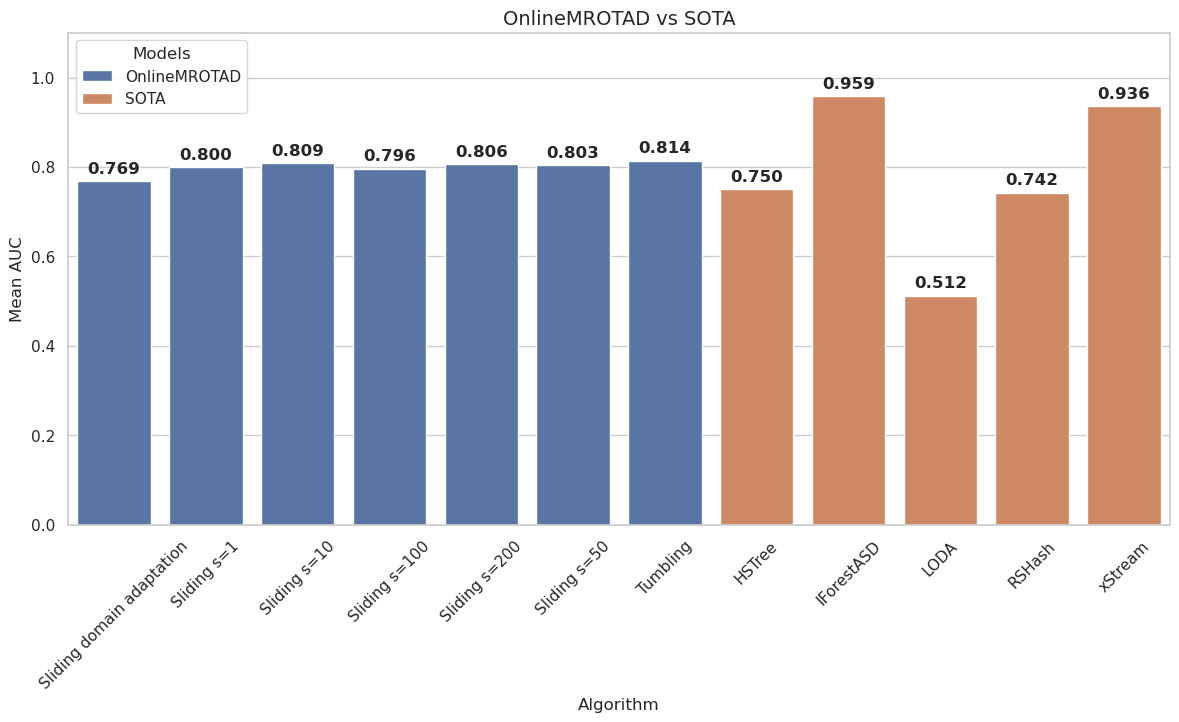

In [ ]:

combined_means = pd.concat([pivot_auc.mean(), sota_auc.mean()], axis=0, keys=['OnlineMROTAD', 'SOTA'])

plt.figure(figsize=(12, 6))

plot_df = combined_means.reset_index()
plot_df.columns = ['Category', 'Algorithm', 'Mean_AUC']

ax = sns.barplot(data=plot_df, x='Algorithm', y='Mean_AUC', hue='Category', dodge=False)

plt.title("OnlineMROTAD vs SOTA", fontsize=14)
plt.ylabel("Mean AUC")
plt.ylim(0, 1.1)
plt.legend(title="Models")

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.3f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.xticks(rotation=45)

#plt.savefig("results/mean_auc_comparison.eps", format='eps', bbox_inches='tight')
#plt.savefig("results/mean_auc_comparison.png", bbox_inches='tight')  # PNG pour vérifier visuellement

plt.show()

In [ ]:

combined_std = pd.concat([pivot_auc.std(), sota_auc.std()], axis=0, keys=['OnlineMROTAD', 'SOTA'])


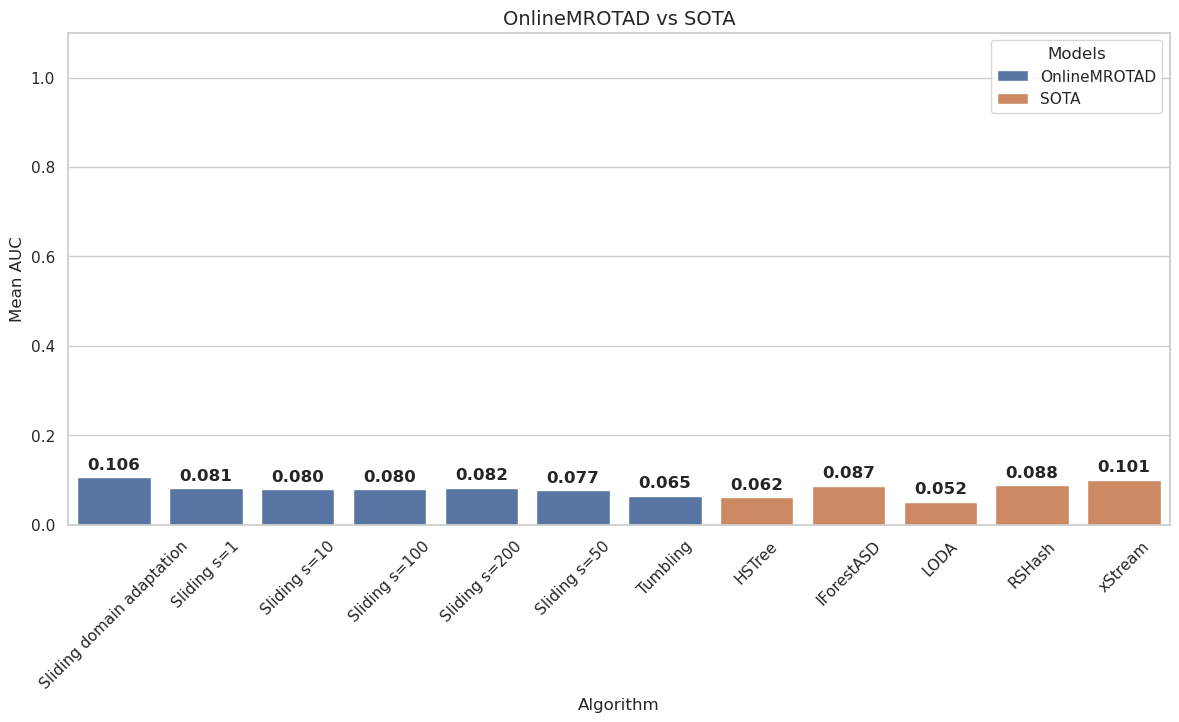

In [ ]:
plot_df1 = combined_std.reset_index()
plot_df1.columns = ['Category', 'Algorithm', 'STD_AUC']
plt.figure(figsize=(12,6))




ax = sns.barplot(data=plot_df, x='Algorithm', y='STD_AUC', hue='Category', dodge=False)

plt.title("OnlineMROTAD vs SOTA", fontsize=14)
plt.ylabel("Mean AUC")
plt.ylim(0, 1.1)
plt.legend(title="Models")

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.3f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.xticks(rotation=45)


plt.show()

In [ ]:
#!pip install scikit-posthocs

In [ ]:
pivot_auc.head()

Method,Sliding domain adaptation,Sliding s=1,Sliding s=10,Sliding s=100,Sliding s=200,Sliding s=50,Tumbling
0,0.5065,0.9110,0.9206,0.8467,0.9093,0.8757,0.9185
1,0.7873,0.8006,0.7978,0.7981,0.7954,0.7994,0.8007
2,0.8227,0.8228,0.8226,0.8231,0.8184,0.8224,0.8221
3,0.6733,0.7124,0.8053,0.6768,0.6624,0.7939,0.8063
4,0.7659,0.7154,0.7151,0.7206,0.8158,0.7192,0.7659


In [ ]:
sota_auc.head()

,HSTree,IForestASD,LODA,RSHash,xStream
0,0.9266,0.9565,0.5001,0.9167,0.9521
1,0.7318,0.9823,0.5000,0.7329,0.9233
2,0.7312,0.9786,0.5000,0.7343,0.9204
3,0.8771,0.9831,0.7246,0.9682,0.9560
4,0.6152,0.6059,0.5002,0.5595,0.5430


In [ ]:
cbm = pd.concat([pivot_auc, sota_auc], axis=1)


Friedman p-value : 0.0000


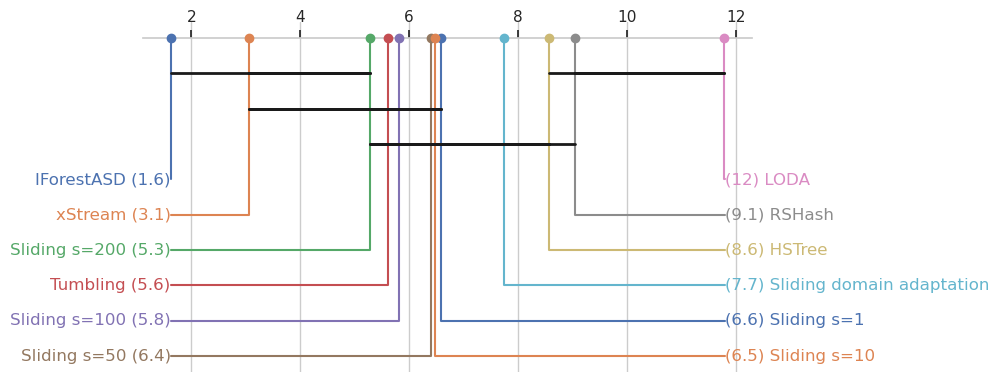

In [ ]:
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare



stat, p = friedmanchisquare(*[cbm[col] for col in cbm.columns])
print(f"Friedman p-value : {p:.4f}")

ranks = cbm.rank(axis=1, ascending=False).mean()

sig_matrix = sp.posthoc_nemenyi_friedman(cbm)

plt.figure(figsize=(10, 4))
sp.critical_difference_diagram(ranks, sig_matrix)
plt.tight_layout()
plt.savefig("../results/cd_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

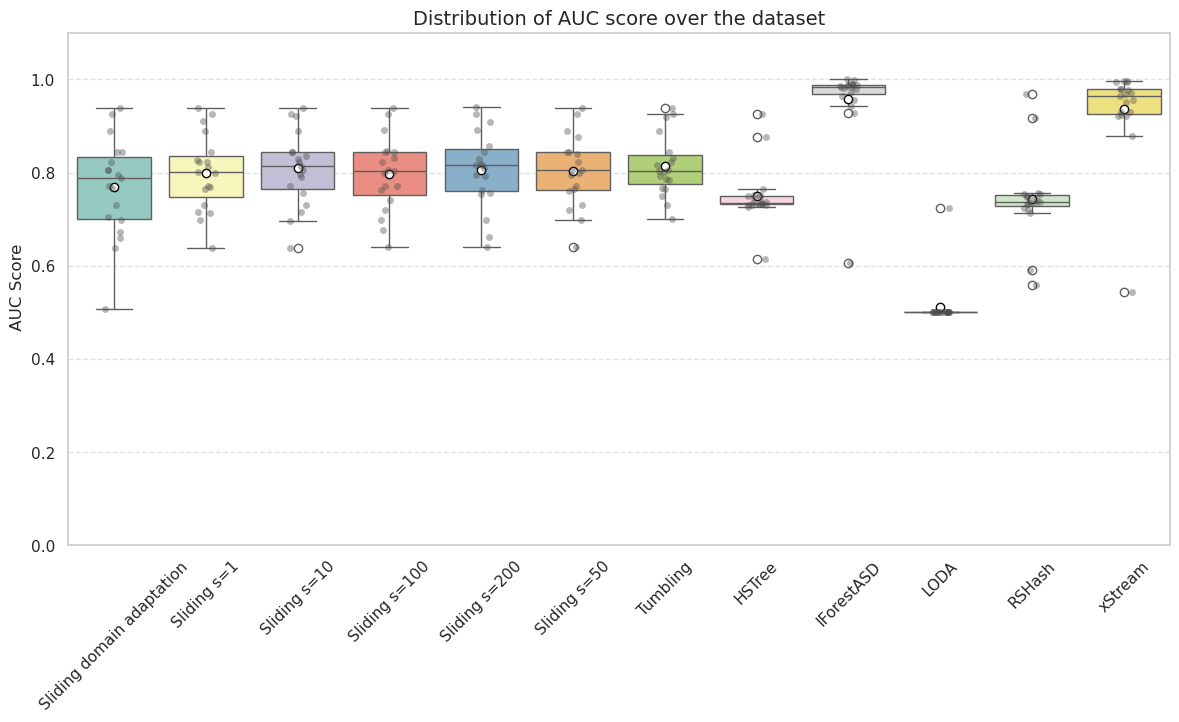

In [ ]:

plt.figure(figsize=(12, 6))

dist_data = pd.concat([pivot_auc, sota_auc], axis=1)

sns.boxplot(data=dist_data, palette="Set3", showmeans=True, 
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
sns.stripplot(data=dist_data, color=".3", alpha=0.4)

plt.title("Distribution of AUC score over the dataset", fontsize=14)
plt.ylabel(" AUC Score")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.xticks(rotation=45)
#plt.savefig("results/auc_distribution_comparison.eps")
plt.show()

In [ ]:
pivot_auc.mean()

Method
Sliding domain adaptation    0.768505
Sliding s=1                  0.799526
Sliding s=10                 0.808774
Sliding s=100                0.796405
Sliding s=200                0.806132
Sliding s=50                 0.803474
Tumbling                     0.814158
dtype: float64

In [ ]:

def generate_latex_summary(csv_path):
    df = pd.read_csv(csv_path)

    idx_max_global = df.sort_values(
        by=['AUC_Global', 'Execution_Time(s)'], 
        ascending=[False, True]
    ).groupby('Dataset')['AUC_Global'].idxmax()
    
    best_configs = df.loc[idx_max_global].copy()

    def format_params(row):
        d = int(row['Num_Drifts'])
        w = int(row['Windows size'])
        t = row['Anomaly threshold']
        o = int(row['offline_size'])
        return f"D:{d}, W:{w}, T:{t}, O:{o}"

    best_configs['Config_Str'] = best_configs.apply(format_params, axis=1)
    params_map = best_configs.set_index('Dataset')['Config_Str'].to_dict()

    df_grouped = df.sort_values(
        by=['AUC_Global', 'Execution_Time(s)'], 
        ascending=[False, True]
    ).groupby(['Dataset', 'Method']).first().reset_index()
    
    pivot_auc = df_grouped.pivot(index='Dataset', columns='Method', values='AUC_Global')
    pivot_time = df_grouped.pivot(index='Dataset', columns='Method', values='Execution_Time(s)')

    methods = pivot_auc.columns.tolist()
    latex_rows = []

    for dataset in pivot_auc.index:
        # Protection des caractères spéciaux LaTeX
        ds_escaped = dataset.replace('_', '\\_')
        config_escaped = params_map.get(dataset, "").replace('_', '\\_')
        
        row_str = f"{ds_escaped} & {config_escaped}"
        
        row_auc_values = pivot_auc.loc[dataset]
        max_auc_row = row_auc_values.max()
        
        for method in methods:
            auc = pivot_auc.loc[dataset, method]
            time = pivot_time.loc[dataset, method]
            
            if pd.isna(auc):
                cell = "N/A"
            else:
                val_text = f"{auc:.4f} ({time:.1f}s)"
                # Mise en gras si c'est le max de la ligne
                if auc == max_auc_row:
                    cell = f"\\textbf{{{val_text}}}"
                else:
                    cell = val_text
            row_str += f" & {cell}"
        
        row_str += " \\\\"
        latex_rows.append(row_str)

    header_methods = " & ".join([f"\\textbf{{{m.replace('_', ' ')}}}" for m in methods])
    col_format = "l" + "c" * (len(methods) + 1)

    latex_code = f"""
\\begin{{sidewaystable}}[htbp]
\\centering
\\caption{{Performances ROC, Temps et Paramètres Optimaux (D:Drifts, W:Window, T:Threshold, O:Offline)}}
\\label{{tab:results_params}}
\\resizebox{{\\textheight}}{{!}}{{%
\\begin{{tabular}}{{{col_format}}}
\\toprule
\\textbf{{Dataset}} & \\textbf{{Best Config}} & {header_methods} \\\\
\\midrule
"""
    latex_code += "\n".join(latex_rows)
    latex_code += """
\\bottomrule
\\end{tabular}
}
\\end{sidewaystable}
"""
    return latex_code, df_grouped


In [ ]:

final_latex, df_grouped = generate_latex_summary('../results/df_total.csv')
        

In [ ]:
def compute_mean_auc_time(csv_path):
    df = pd.read_csv(csv_path)

    mean_stats = (
        df.groupby(['Dataset', 'Method'])[['AUC_Global', 'Execution_Time(s)']]
        .mean()
        .reset_index()
    )

    return mean_stats


In [ ]:
time = compute_mean_auc_time('../results/df_total.csv')

In [ ]:
online = time.pivot(index='Dataset', columns='Method', values=['Execution_Time(s)'])

In [ ]:
online

Execution_Time(s)                    \
Method                      sliding_window_1 sliding_window_10   
Dataset                                                          
COIL20_mix_sudden                1846.121667        190.086667   
Ionosphere_shake_gradual          222.605000         24.013333   
Ionosphere_shake_sudden_2         301.681667         30.405000   
S1                                 59.895000          7.575000   
S2                                 18.943333          2.006667   
WOBC_shake_gradual_2              252.943333         25.621667   
WOBC_shake_sudden                 147.993333         16.631667   
dermatology_shake_gradual         268.671667         27.618333   
dermatology_shake_sudden_2        299.421667         31.625000   
glass_shake_gradual_2             262.086667         28.076667   
glass_shake_sudden_2              644.016667         25.560000   
mice_shake_gradual_2              444.795000         42.770000   
mice_shake_sudden                 249.456667         25.656667   
seeds_shake_gradual               190.708333         20.616667   
thyroid_shake_gradual             177.228333         17.106667   
vowel_shake_gradual               202.835000         20.216667   
vowel_shake_sudden_2              260.068333         26.138333   
wine_shake_sudden                 584.401667         15.835000   
wine_shake_sudden_2               257.910000         26.378333   

                                                                  \
Method                     sliding_window_100 sliding_window_200   
Dataset                                                            
COIL20_mix_sudden                  331.931667          15.795000   
Ionosphere_shake_gradual             2.365000           1.245000   
Ionosphere_shake_sudden_2            3.216667           1.595000   
S1                                   0.740000           0.341667   
S2                                   0.210000           0.105000   
WOBC_shake_gradual_2                 2.781667           1.333333   
WOBC_shake_sudden                    1.595000           0.808333   
dermatology_shake_gradual            3.398333           2.450000   
dermatology_shake_sudden_2           4.128333           2.323333   
glass_shake_gradual_2                2.945000           1.485000   
glass_shake_sudden_2                 2.645000           1.425000   
mice_shake_gradual_2                 5.116667           2.620000   
mice_shake_sudden                    2.558333           1.358333   
seeds_shake_gradual                  2.786667           2.035000   
thyroid_shake_gradual                1.836667           0.990000   
vowel_shake_gradual                  2.186667           1.106667   
vowel_shake_sudden_2                 2.750000           1.336667   
wine_shake_sudden                    1.638333           0.810000   
wine_shake_sudden_2                  2.720000           1.425000   

                                                                \
Method                     sliding_window_50 tumbling_window_1   
Dataset                                                          
COIL20_mix_sudden                  47.898333         21.560000   
Ionosphere_shake_gradual            4.691667          2.105000   
Ionosphere_shake_sudden_2           6.133333          2.663333   
S1                                  1.838333          1.093333   
S2                                  0.425000          0.153333   
WOBC_shake_gradual_2                5.233333          2.075000   
WOBC_shake_sudden                   3.098333          1.595000   
dermatology_shake_gradual           6.296667          3.425000   
dermatology_shake_sudden_2          7.771667          3.563333   
glass_shake_gradual_2               5.520000          2.210000   
glass_shake_sudden_2                5.150000          1.965000   
mice_shake_gradual_2                8.950000          4.175000   
mice_shake_sudden                   5.366667          2.175000   
seeds_shake_gradual  

In [ ]:
online.columns

MultiIndex([('Execution_Time(s)',                'sliding_window_1'),
            ('Execution_Time(s)',               'sliding_window_10'),
            ('Execution_Time(s)',              'sliding_window_100'),
            ('Execution_Time(s)',              'sliding_window_200'),
            ('Execution_Time(s)',               'sliding_window_50'),
            ('Execution_Time(s)',               'tumbling_window_1'),
            ('Execution_Time(s)', 'tumbling_window_domain_adaption')],
           names=[None, 'Method'])

In [ ]:
online = online.reset_index()

In [ ]:
online.columns = online.columns.droplevel(0)


In [ ]:
test = online[[ 'sliding_window_1', 'sliding_window_10', 'sliding_window_100',
       'sliding_window_200', 'sliding_window_50', 'tumbling_window_1',
       'tumbling_window_domain_adaption']]

In [ ]:
online.columns

Index(['', 'sliding_window_1', 'sliding_window_10', 'sliding_window_100',
       'sliding_window_200', 'sliding_window_50', 'tumbling_window_1',
       'tumbling_window_domain_adaption'],
      dtype='object', name='Method')

In [ ]:
time_sota = pd.read_csv("../results/pivot_time_sota.csv")   

In [ ]:
time_sota.head()

,Dataset,HSTree,IForestASD,LODA,RSHash,xStream
0,COIL20_mix_sudden,423.754533,1898.944300,315.603167,97.024633,6500.90630
1,Ionosphere_shake_gradual,564.905367,289.639133,358.535367,883.348400,5788.90275
2,Ionosphere_shake_sudden_2,707.107233,302.726600,447.538000,164.750367,7433.17800
3,S1,317.373450,37.952500,192.718300,44.334150,4157.02470
4,S2,123.268800,22.282700,81.245350,18.158600,899.90125


In [ ]:
df_melted = pd.melt(time_sota, id_vars=['Dataset'], value_vars=['HSTree', 'IForestASD', 'LODA', 'RSHash', 'xStream'],
                    var_name='Method', value_name='Value')

print(df_melted.head())

                     Dataset  Method       Value
0          COIL20_mix_sudden  HSTree  423.754533
1   Ionosphere_shake_gradual  HSTree  564.905367
2  Ionosphere_shake_sudden_2  HSTree  707.107233
3                         S1  HSTree  317.373450
4                         S2  HSTree  123.268800


In [ ]:
online.columns

Index(['', 'sliding_window_1', 'sliding_window_10', 'sliding_window_100',
       'sliding_window_200', 'sliding_window_50', 'tumbling_window_1',
       'tumbling_window_domain_adaption'],
      dtype='object', name='Method')

In [ ]:
online_melted = pd.melt(online, id_vars=[''], var_name='Method', value_name='Value')
online_melted = online_melted.rename(columns={'Unnamed: 0': 'Dataset'})
online_melted['Method'] = online_melted['Method'].apply(change_name)
print(online_melted.head())

                                   Method        Value
0          COIL20_mix_sudden  Sliding s=1  1846.121667
1   Ionosphere_shake_gradual  Sliding s=1   222.605000
2  Ionosphere_shake_sudden_2  Sliding s=1   301.681667
3                         S1  Sliding s=1    59.895000
4                         S2  Sliding s=1    18.943333


In [ ]:
df_melted_labeled = df_melted.copy()
df_melted_labeled['Source'] = 'SOTA'

online_melted_labeled = online_melted.copy()
online_melted_labeled['Source'] = 'OnlineMROTAD'

combined_df = pd.concat([df_melted_labeled, online_melted_labeled], ignore_index=True)

print(combined_df.head())
print(combined_df.tail())


                     Dataset  Method       Value Source     
0          COIL20_mix_sudden  HSTree  423.754533   SOTA  NaN
1   Ionosphere_shake_gradual  HSTree  564.905367   SOTA  NaN
2  Ionosphere_shake_sudden_2  HSTree  707.107233   SOTA  NaN
3                         S1  HSTree  317.373450   SOTA  NaN
4                         S2  HSTree  123.268800   SOTA  NaN
    Dataset                     Method       Value        Source  \
223     NaN  Sliding domain adaptation   73.076667  OnlineMROTAD   
224     NaN  Sliding domain adaptation   81.923333  OnlineMROTAD   
225     NaN  Sliding domain adaptation  105.133333  OnlineMROTAD   
226     NaN  Sliding domain adaptation   61.496667  OnlineMROTAD   
227     NaN  Sliding domain adaptation  102.683333  OnlineMROTAD   

                            
223  thyroid_shake_gradual  
224    vowel_shake_gradual  
225   vowel_shake_sudden_2  
226      wine_shake_sudden  
227    wine_shake_sudden_2  


In [ ]:
average_execution_time = combined_df.groupby(['Source', 'Method'])['Value'].mean().reset_index()

print(average_execution_time.head())

         Source                     Method       Value
0  OnlineMROTAD  Sliding domain adaptation  177.961053
1  OnlineMROTAD                Sliding s=1  352.199123
2  OnlineMROTAD               Sliding s=10   31.786228
3  OnlineMROTAD              Sliding s=100   19.871053
4  OnlineMROTAD              Sliding s=200    2.136228


In [ ]:
#online.to_csv('../results/onlinemrottime.csv', index=False)

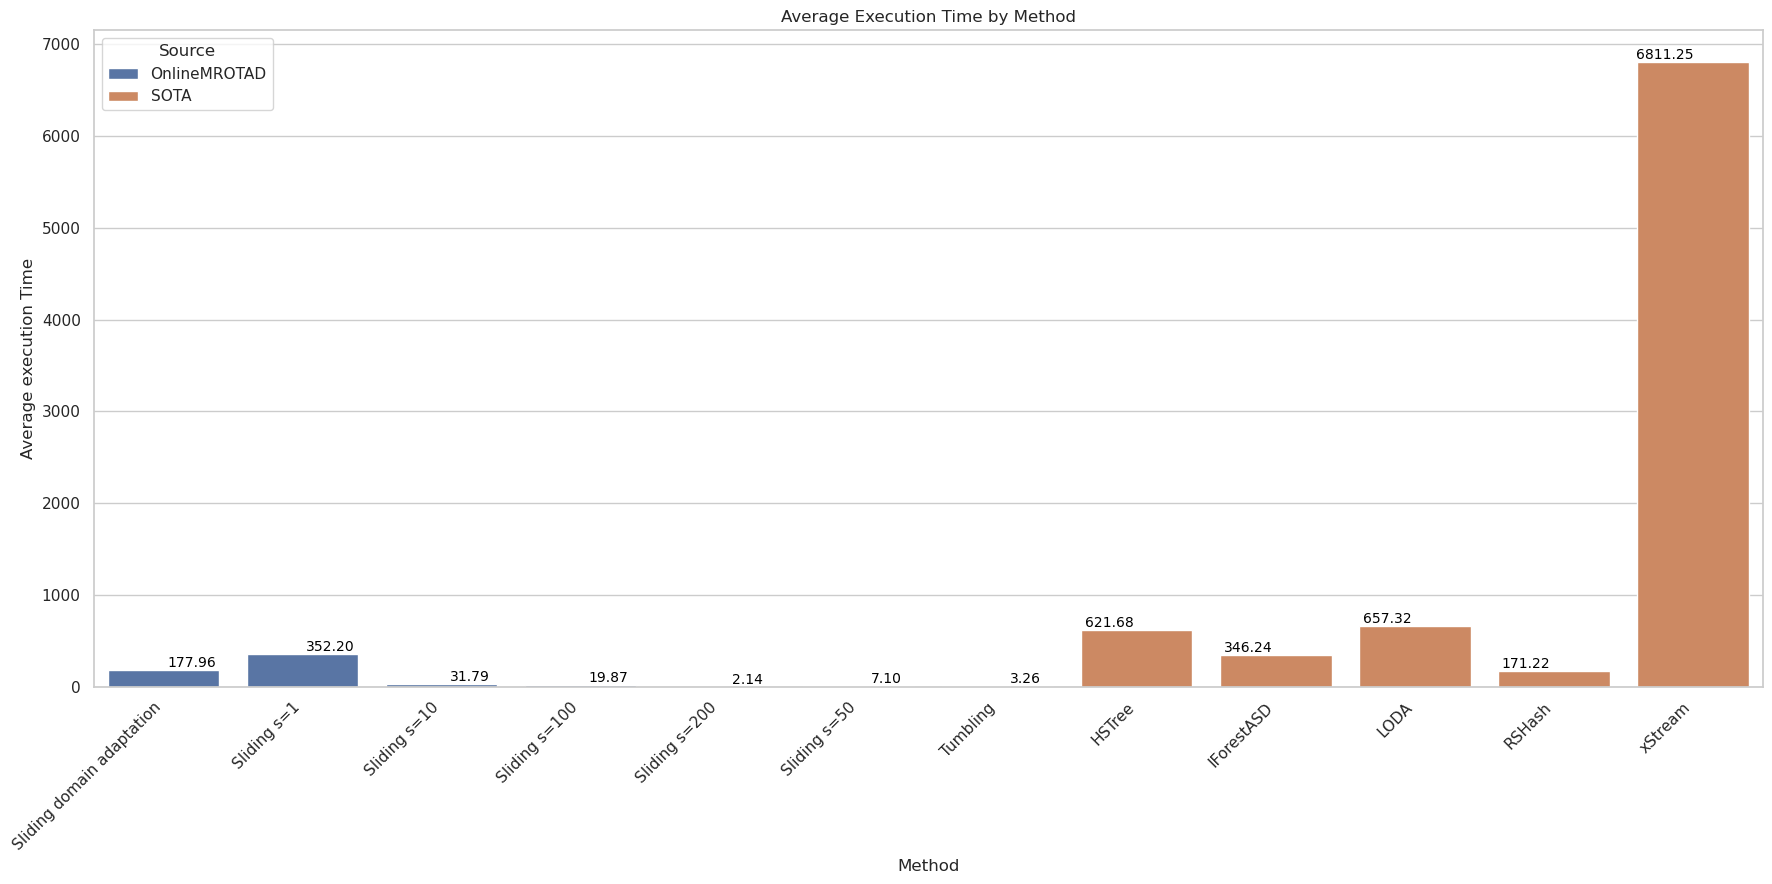

In [ ]:

plt.figure(figsize=(18, 9))
sns.barplot(data=average_execution_time, x='Method', y='Value', hue='Source')
plt.xlabel('Method')
plt.ylabel('Average execution Time')
plt.title('Average Execution Time by Method')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Source')

for index, row in average_execution_time.iterrows():
    plt.text(x=index - (0.2 if row['Source'] == 'SOTA' else -0.2), y=row['Value'], s=f"{row['Value']:.2f}", color='black', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
#plt.savefig("../results/averagetime.png")
plt.show()

In [ ]:
average_execution_time

,Source,Method,Value
0,OnlineMROTAD,Sliding domain adaptation,177.961053
1,OnlineMROTAD,Sliding s=1,352.199123
2,OnlineMROTAD,Sliding s=10,31.786228
3,OnlineMROTAD,Sliding s=100,19.871053
4,OnlineMROTAD,Sliding s=200,2.136228
5,OnlineMROTAD,Sliding s=50,7.095702
6,OnlineMROTAD,Tumbling,3.262281
7,SOTA,HSTree,621.684476
8,SOTA,IForestASD,346.240565
9,SOTA,LODA,657.321564


In [ ]:
average_execution_time

,Source,Method,Value
0,OnlineMROTAD,Sliding domain adaptation,177.961053
1,OnlineMROTAD,Sliding s=1,352.199123
2,OnlineMROTAD,Sliding s=10,31.786228
3,OnlineMROTAD,Sliding s=100,19.871053
4,OnlineMROTAD,Sliding s=200,2.136228
5,OnlineMROTAD,Sliding s=50,7.095702
6,OnlineMROTAD,Tumbling,3.262281
7,SOTA,HSTree,621.684476
8,SOTA,IForestASD,346.240565
9,SOTA,LODA,657.321564


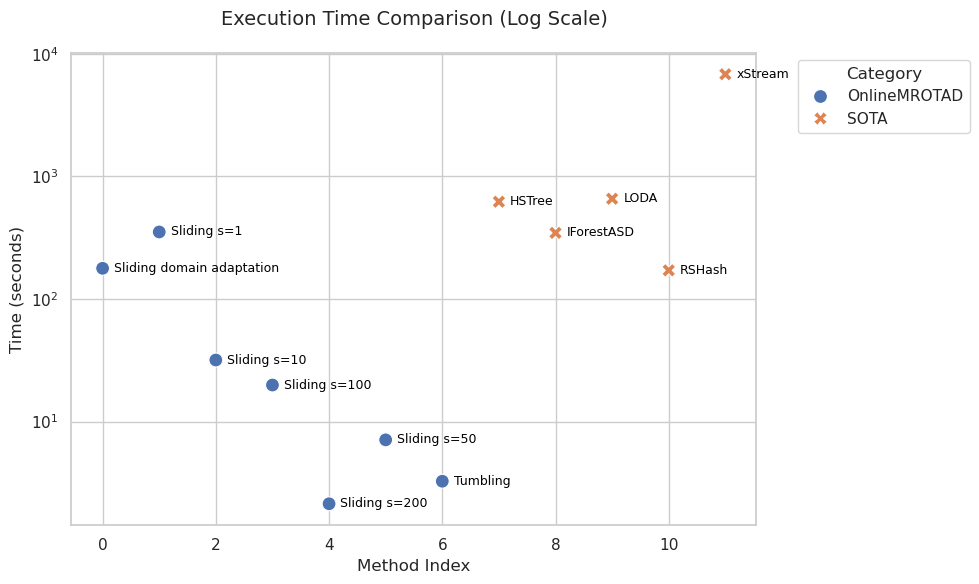

In [ ]:


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))


plot = sns.scatterplot(
    data=average_execution_time, 
    x=average_execution_time.index, 
    y='Value', 
    hue='Source', 
    style='Source', 
    s=100
)

for i in range(average_execution_time.shape[0]):
    plt.text(
        x=i + 0.2, 
        y=average_execution_time.Value[i], 
        s=average_execution_time.Method[i], 
        fontdict=dict(color='black', size=9),
        verticalalignment='center'
    )

# 5. Passage en échelle logarithmique pour la lisibilité
plot.set_yscale("log")

plt.title("Execution Time Comparison (Log Scale)", fontsize=14, pad=20)
plt.xlabel("Method Index", fontsize=12)
plt.ylabel("Time (seconds)", fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig('../results/pareto front.png')
plt.show()

In [ ]:

import re


def plot_auc_with_drift(auc_lists, drift_indicators, xlabel="time", ylabel="auc", 
                        figsize=(16, 6), 
                        title="AUC Scores Over Time with Concept Drift Detection"):

    
    def parse_truncated_list(list_str):
        """
        Parse une liste qui peut être tronquée (sans crochet fermant ou avec '...')
        """
        if not isinstance(list_str, str):
            return list_str
        
        list_str = list_str.strip()
        
        if not list_str.startswith('['):
            return list_str
        
        if list_str.endswith(']'):
            try:
                return eval(list_str)
            except:
                pass

        numbers = re.findall(r'-?\d+\.?\d*', list_str)
        if numbers:
            try:
                # Convertir en float
                result = [float(n) for n in numbers]
                print(f" Données tronquées détectées - {len(result)} valeurs extraites")
                return result
            except:
                pass

        bool_str = list_str.replace('True', '1').replace('False', '0')
        numbers = re.findall(r'\d+', bool_str)
        if numbers:
            result = [bool(int(n)) for n in numbers]
            print(f"  Données booléennes tronquées - {len(result)} valeurs extraites")
            return result
        
        raise ValueError(f"Impossible de parser la liste: {list_str[:100]}...")
    
    try:
        print("\n Traitement de auc_lists...")
        auc_lists = parse_truncated_list(auc_lists)
        auc_lists = np.array(auc_lists, dtype=float)
        
        if auc_lists.size == 0:
            raise ValueError("auc_lists est vide après parsing")
        
        if auc_lists.ndim == 0:
            auc_lists = np.array([auc_lists])
        
        print(f" {len(auc_lists)} valeurs AUC chargées")
            
    except Exception as e:
        raise TypeError(f"Erreur lors de la conversion de auc_lists: {e}\n"
                       f"Type reçu: {type(auc_lists)}\n"
                       f"Aperçu: {str(auc_lists)[:200]}...")
    
    try:
        print(" Traitement de drift_indicators...")
        drift_indicators = parse_truncated_list(drift_indicators)
        drift_indicators = np.array(drift_indicators, dtype=bool)
        
        if drift_indicators.size == 0:
            raise ValueError("drift_indicators est vide après parsing")
            
        if drift_indicators.ndim == 0:
            drift_indicators = np.array([drift_indicators])
        
        print(f" {len(drift_indicators)} indicateurs de drift chargés")
            
    except Exception as e:
        raise TypeError(f"Erreur lors de la conversion de drift_indicators: {e}\n"
                       f"Type reçu: {type(drift_indicators)}\n"
                       f"Aperçu: {str(drift_indicators)[:200]}...")
    
    # AJUSTER LES LONGUEURS
    if len(auc_lists) != len(drift_indicators):
        min_len = min(len(auc_lists), len(drift_indicators))
        print(f"  Ajustement: AUC={len(auc_lists)}, Drift={len(drift_indicators)} → {min_len}")
        auc_lists = auc_lists[:min_len]
        drift_indicators = drift_indicators[:min_len]
    
    # CRÉER LE GRAPHIQUE
    fig, ax = plt.subplots(figsize=figsize)
    
    # Tracer la courbe AUC
    x_values = range(len(auc_lists))
    ax.plot(x_values, auc_lists, linewidth=2, color='blue', marker='o', 
            markersize=3, alpha=0.7, label='AUC Score')
    
    # Zones de drift
    drift_count = 0
    drift_positions = []
    for i in range(len(drift_indicators)):
        if drift_indicators[i]:
            ax.axvspan(i-0.5, i+0.5, alpha=0.3, color='red')
            drift_count += 1
            drift_positions.append(i)
    
    
    legend_elements = [
        plt.Line2D([0], [0], color='blue', linewidth=2, marker='o', 
                   markersize=5, label='AUC Score'),
        Patch(facecolor='red', alpha=0.3, 
              label=f'Concept Drift ({drift_count} détectés)')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=10)
    
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    plt.tight_layout()
    #plt.savefig()
    plt.show()
    
    return fig, ax



In [ ]:
Score_List = df_max.iloc[0]["Score_List"]
Drift_List = df_max.iloc[0]["Drift_List"]
AUC_List    = df_max.iloc[0]["AUC_List"]


 Traitement de auc_lists...
 2900 valeurs AUC chargées
 Traitement de drift_indicators...
 2900 indicateurs de drift chargés


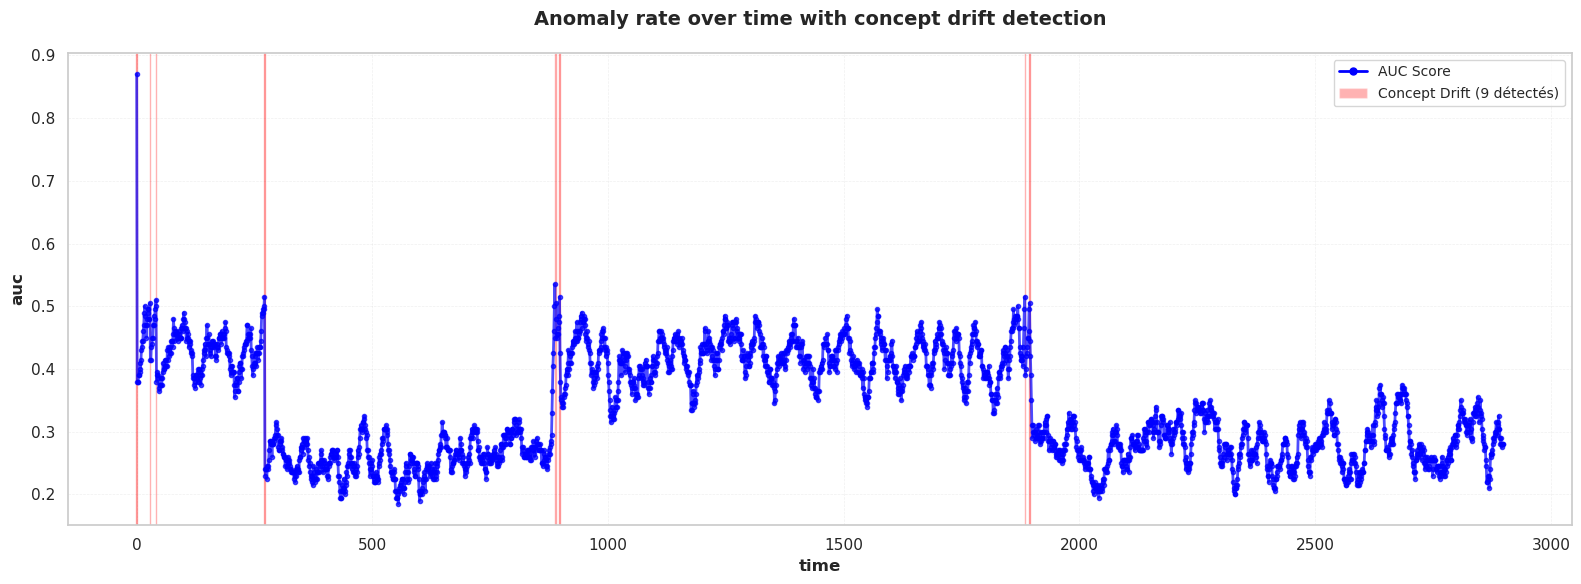

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'Anomaly rate over time with concept drift detection'}, xlabel='time', ylabel='auc'>)

In [ ]:
plot_auc_with_drift(Score_List, Drift_List,  title="Anomaly rate over time with concept drift detection")

In [ ]:

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_auc_with_drift2(auc_lists, drift_indicators,
                        dataset=None, anomaly_rate=None, window_size=None,
                        offline_size=None, method=None,
                        xlabel="Time", ylabel="Score",
                        figsize=(16, 6)):

    def parse_truncated_list(list_str):
        if not isinstance(list_str, str):
            return list_str
        list_str = list_str.strip()
        if not list_str.startswith('['):
            return list_str
        if list_str.endswith(']'):
            try:
                return eval(list_str)
            except:
                pass
        numbers = re.findall(r'-?\d+\.?\d*', list_str)
        if numbers:
            try:
                result = [float(n) for n in numbers]
                return result
            except:
                pass
        bool_str = list_str.replace('True', '1').replace('False', '0')
        numbers = re.findall(r'\d+', bool_str)
        if numbers:
            return [bool(int(n)) for n in numbers]
        raise ValueError(f"Impossible de parser la liste: {list_str[:100]}...")

    # --- Parsing ---
    auc_lists = np.array(parse_truncated_list(auc_lists), dtype=float)
    drift_indicators = np.array(parse_truncated_list(drift_indicators), dtype=bool)

    if len(auc_lists) != len(drift_indicators):
        min_len = min(len(auc_lists), len(drift_indicators))
        auc_lists = auc_lists[:min_len]
        drift_indicators = drift_indicators[:min_len]

    # --- Titre sur deux lignes ---
    line1 = f"Anomaly Score over Time with Concept Drift Detection"
    parts = []
    if dataset      is not None: parts.append(f"Dataset: {dataset}")
    if method       is not None: parts.append(f"Method: {method}")
    if anomaly_rate is not None: parts.append(f"Anomaly rate: {anomaly_rate}")
    if window_size  is not None: parts.append(f"Window size: {window_size}")
    if offline_size is not None: parts.append(f"Offline size: {offline_size}")
    line2 = "   |   ".join(parts)
    full_title = f"{line1}\n{line2}" if line2 else line1

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(range(len(auc_lists)), auc_lists,
            linewidth=2, color='steelblue', marker='o',
            markersize=3, alpha=0.8)

    drift_count = 0
    for i, is_drift in enumerate(drift_indicators):
        if is_drift:
            ax.axvspan(i - 0.5, i + 0.5, alpha=0.3, color='red', zorder=0)
            drift_count += 1

    legend_elements = [
        Line2D([0], [0], color='steelblue', linewidth=2, marker='o',
               markersize=5, label='Score'),
        Patch(facecolor='red', alpha=0.3,
              label=f'Concept Drift ({drift_count} detected)')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=10)

    ax.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.set_title(full_title, fontsize=13, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    plt.savefig(f"../results/images/Dataset: {dataset} {method}.png")
    plt.tight_layout()
    plt.show()

    return fig, ax
